In [1]:
# ============================================================
# CELL 1: Setup + Load financial test set
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, torch, json

class Config:
    PROJECT_ROOT    = '/content/drive/MyDrive/FinDocVQA'
    FINANCIAL_ANNOT = os.path.join(PROJECT_ROOT, 'data/financial_test/annotations')
    FINANCIAL_IMGS  = os.path.join(PROJECT_ROOT, 'data/financial_test/images/manual')
    OUTPUTS_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
    SEED = 42

cfg = Config()

# Load financial test set
with open(os.path.join(cfg.FINANCIAL_ANNOT, 'combined_financial_vqa_dataset_fixed_types.json'), 'r') as f:
    fin_data = json.load(f)

# Build eval pairs — map image paths to Drive location
eval_pairs = []
for entry in fin_data:
    ticker = entry['ticker']
    fname = entry['image_path']
    # Image is at: images/manual/TICKER/filename
    img_path = os.path.join(cfg.FINANCIAL_IMGS, ticker, fname)

    if not os.path.exists(img_path):
        print(f"⚠️ Missing: {img_path}")
        continue

    for q in entry['questions']:
        eval_pairs.append({
            'image_path': img_path,
            'ticker': ticker,
            'company': entry['company'],
            'image_type': entry['image_type'],
            'question': q['question'],
            'answer': q['answer'],
            'question_type': q['type'],
        })

from collections import Counter
type_counts = Counter(p['question_type'] for p in eval_pairs)
company_counts = Counter(p['ticker'] for p in eval_pairs)

print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ Financial test set loaded")
print(f"  Total QA pairs: {len(eval_pairs)}")
print(f"  Question types: {dict(type_counts)}")
print(f"  Companies: {len(company_counts)}")
print(f"  Missing images: {sum(len(e['questions']) for e in fin_data) - len(eval_pairs)}")

Mounted at /content/drive
✓ GPU: Tesla T4
✓ Financial test set loaded
  Total QA pairs: 397
  Question types: {'extractive': 243, 'numerical_reasoning': 65, 'layout_understanding': 72, 'chart_interpretation': 17}
  Companies: 10
  Missing images: 0


In [2]:
# ============================================================
# CELL 2: Install + metrics + evaluate function
# ============================================================

%%capture
!pip install transformers accelerate datasets sentencepiece protobuf pytesseract
!apt-get -qq install tesseract-ocr

# ---
import numpy as np
from PIL import Image
from tqdm import tqdm
import time
import json

def normalized_levenshtein(s1, s2):
    s1, s2 = s1.lower().strip(), s2.lower().strip()
    if s1 == s2:
        return 1.0
    if len(s1) == 0 or len(s2) == 0:
        return 0.0
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return 1.0 - (dp[m][n] / max(m, n))

def compute_anls(prediction, ground_truth, threshold=0.5):
    if not prediction:
        return 0.0
    score = normalized_levenshtein(prediction, ground_truth)
    return score if score >= threshold else 0.0

def compute_exact_match(prediction, ground_truth):
    return float(prediction.lower().strip() == ground_truth.lower().strip())

def evaluate_model(predict_fn, eval_pairs, model_name):
    results = []
    anls_scores = []
    em_scores = []
    type_anls = {}
    type_em = {}

    print(f"\nEvaluating {model_name} on {len(eval_pairs)} financial QA pairs...")
    print("=" * 60)

    start = time.time()

    for pair in tqdm(eval_pairs, desc=model_name):
        try:
            img = Image.open(pair['image_path']).convert('RGB')
            prediction = predict_fn(img, pair['question'])
        except Exception as e:
            prediction = ""

        anls = compute_anls(prediction, pair['answer'])
        em = compute_exact_match(prediction, pair['answer'])

        anls_scores.append(anls)
        em_scores.append(em)

        qtype = pair['question_type']
        if qtype not in type_anls:
            type_anls[qtype] = []
            type_em[qtype] = []
        type_anls[qtype].append(anls)
        type_em[qtype].append(em)

        results.append({
            'ticker': pair['ticker'],
            'question': pair['question'],
            'ground_truth': pair['answer'],
            'prediction': prediction,
            'question_type': qtype,
            'anls': anls,
            'exact_match': em,
        })

    elapsed = time.time() - start

    print(f"\n{model_name} RESULTS")
    print("=" * 60)
    print(f"  Overall ANLS:  {np.mean(anls_scores):.4f}")
    print(f"  Overall EM:    {np.mean(em_scores):.4f}")
    print(f"  Time: {elapsed:.0f}s ({elapsed/len(eval_pairs):.1f}s/example)")
    print(f"\n  Per question type:")
    for qtype in sorted(type_anls.keys()):
        a = np.mean(type_anls[qtype])
        e = np.mean(type_em[qtype])
        n = len(type_anls[qtype])
        print(f"    {qtype:25s}: ANLS={a:.4f}  EM={e:.4f}  (n={n})")

    return {
        'model': model_name,
        'overall_anls': float(np.mean(anls_scores)),
        'overall_em': float(np.mean(em_scores)),
        'per_type': {t: {'anls': float(np.mean(v)), 'em': float(np.mean(type_em[t])), 'n': len(v)}
                     for t, v in type_anls.items()},
        'per_example': results,
        'time': elapsed
    }

print("✓ Metrics and evaluation function ready")

In [3]:
# ============================================================
# CELL 3: Pix2Struct
# ============================================================

from transformers import Pix2StructProcessor, Pix2StructForConditionalGeneration

print("Loading Pix2Struct...")
p2s_processor = Pix2StructProcessor.from_pretrained('google/pix2struct-docvqa-base')
p2s_model = Pix2StructForConditionalGeneration.from_pretrained('google/pix2struct-docvqa-base')
p2s_model = p2s_model.to('cuda')
p2s_model.eval()
print("✓ Loaded")

def pix2struct_predict(image, question):
    inputs = p2s_processor(images=image, text=question, return_tensors="pt", max_patches=2048).to('cuda')
    with torch.no_grad():
        generated = p2s_model.generate(**inputs, max_new_tokens=256)
    return p2s_processor.decode(generated[0], skip_special_tokens=True)

p2s_results = evaluate_model(pix2struct_predict, eval_pairs, "Pix2Struct")
with open(os.path.join(cfg.OUTPUTS_DIR, 'final_pix2struct_results.json'), 'w') as f:
    json.dump(p2s_results, f, indent=2)
print("✓ Saved")

Loading Pix2Struct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

The image processor of type `Pix2StructImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

✓ Loaded

Evaluating Pix2Struct on 397 financial QA pairs...


Pix2Struct:   0%|          | 0/397 [00:00<?, ?it/s]

Arial.TTF: 0.00B [00:00, ?B/s]

Pix2Struct: 100%|██████████| 397/397 [05:03<00:00,  1.31it/s]


Pix2Struct RESULTS
  Overall ANLS:  0.1372
  Overall EM:    0.0831
  Time: 303s (0.8s/example)

  Per question type:
    chart_interpretation     : ANLS=0.1176  EM=0.1176  (n=17)
    extractive               : ANLS=0.1949  EM=0.1111  (n=243)
    layout_understanding     : ANLS=0.0556  EM=0.0556  (n=72)
    numerical_reasoning      : ANLS=0.0169  EM=0.0000  (n=65)
✓ Saved


In [4]:
# ============================================================
# CELL 4: Donut
# ============================================================

from transformers import DonutProcessor, VisionEncoderDecoderModel
import re

p2s_model.cpu()
del p2s_model
torch.cuda.empty_cache()

print("Loading Donut...")
donut_processor = DonutProcessor.from_pretrained('naver-clova-ix/donut-base-finetuned-docvqa')
donut_model = VisionEncoderDecoderModel.from_pretrained('naver-clova-ix/donut-base-finetuned-docvqa')
donut_model = donut_model.to('cuda')
donut_model.eval()
print("✓ Loaded")

def donut_predict(image, question):
    prompt = f"<s_docvqa><s_question>{question}</s_question><s_answer>"
    inputs = donut_processor(image, prompt, return_tensors="pt").to('cuda')
    with torch.no_grad():
        outputs = donut_model.generate(
            **inputs,
            max_length=donut_model.decoder.config.max_position_embeddings,
            pad_token_id=donut_processor.tokenizer.pad_token_id,
            eos_token_id=donut_processor.tokenizer.eos_token_id,
            use_cache=True,
        )
    decoded = donut_processor.batch_decode(outputs, skip_special_tokens=False)[0]
    match = re.search(r'<s_answer>(.*?)</s_answer>', decoded)
    if match:
        return match.group(1).strip()
    decoded = decoded.replace('<s_docvqa>', '').replace('<s_question>', '')
    decoded = decoded.replace('</s_question>', '').replace('<s_answer>', '')
    decoded = decoded.replace('</s_answer>', '').replace('</s>', '').replace('<s>', '')
    return decoded.strip()

donut_results = evaluate_model(donut_predict, eval_pairs, "Donut")
with open(os.path.join(cfg.OUTPUTS_DIR, 'final_donut_results.json'), 'w') as f:
    json.dump(donut_results, f, indent=2)
print("✓ Saved")

Loading Donut...


preprocessor_config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

...

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/803M [00:00<?, ?B/s]

✓ Loaded

Evaluating Donut on 397 financial QA pairs...


Donut: 100%|██████████| 397/397 [10:05<00:00,  1.52s/it]


Donut RESULTS
  Overall ANLS:  0.1046
  Overall EM:    0.0554
  Time: 605s (1.5s/example)

  Per question type:
    chart_interpretation     : ANLS=0.0000  EM=0.0000  (n=17)
    extractive               : ANLS=0.1557  EM=0.0864  (n=243)
    layout_understanding     : ANLS=0.0511  EM=0.0139  (n=72)
    numerical_reasoning      : ANLS=0.0000  EM=0.0000  (n=65)
✓ Saved


In [5]:
# ============================================================
# CELL 5: LayoutLMv3
# ============================================================

from transformers import LayoutLMv3Processor, LayoutLMv3ForQuestionAnswering

donut_model.cpu()
del donut_model
torch.cuda.empty_cache()

print("Loading LayoutLMv3...")
lmv3_processor = LayoutLMv3Processor.from_pretrained('rubentito/layoutlmv3-base-mpdocvqa', apply_ocr=True)
lmv3_model = LayoutLMv3ForQuestionAnswering.from_pretrained('rubentito/layoutlmv3-base-mpdocvqa')
lmv3_model = lmv3_model.to('cuda')
lmv3_model.eval()
print("✓ Loaded")

def layoutlmv3_predict(image, question):
    encoding = lmv3_processor(image, question, return_tensors="pt",
                               max_length=512, truncation=True, padding="max_length")
    encoding = {k: v.to('cuda') for k, v in encoding.items()}
    with torch.no_grad():
        outputs = lmv3_model(**encoding)
    start_idx = torch.argmax(outputs.start_logits, dim=1).item()
    end_idx = torch.argmax(outputs.end_logits, dim=1).item()
    if end_idx < start_idx:
        end_idx = start_idx
    input_ids = encoding['input_ids'][0]
    answer_tokens = input_ids[start_idx : end_idx + 1]
    return lmv3_processor.tokenizer.decode(answer_tokens, skip_special_tokens=True).strip()

lmv3_results = evaluate_model(layoutlmv3_predict, eval_pairs, "LayoutLMv3")
with open(os.path.join(cfg.OUTPUTS_DIR, 'final_layoutlmv3_results.json'), 'w') as f:
    json.dump(lmv3_results, f, indent=2)
print("✓ Saved")

Loading LayoutLMv3...


preprocessor_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

LayoutLMv3ForQuestionAnswering LOAD REPORT from: rubentito/layoutlmv3-base-mpdocvqa
Key                                | Status     |  | 
-----------------------------------+------------+--+-
layoutlmv3.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

✓ Loaded

Evaluating LayoutLMv3 on 397 financial QA pairs...



LayoutLMv3: 100%|██████████| 397/397 [11:11<00:00,  1.69s/it]


LayoutLMv3 RESULTS
  Overall ANLS:  0.1535
  Overall EM:    0.1033
  Time: 671s (1.7s/example)

  Per question type:
    chart_interpretation     : ANLS=0.1029  EM=0.0588  (n=17)
    extractive               : ANLS=0.1916  EM=0.1193  (n=243)
    layout_understanding     : ANLS=0.1674  EM=0.1528  (n=72)
    numerical_reasoning      : ANLS=0.0088  EM=0.0000  (n=65)
✓ Saved


In [6]:
# ============================================================
# CELL 6: OCR + RoBERTa Baseline
# ============================================================

import pytesseract
from transformers import pipeline

lmv3_model.cpu()
del lmv3_model
torch.cuda.empty_cache()

print("Loading RoBERTa QA baseline...")
qa_pipeline = pipeline("question-answering", model="deepset/roberta-base-squad2", device=0)
print("✓ Loaded")

def ocr_roberta_predict(image, question):
    ocr_text = pytesseract.image_to_string(image.convert('RGB'))
    if not ocr_text.strip():
        return ""
    try:
        result = qa_pipeline(question=question, context=ocr_text[:4000])
        return result['answer']
    except:
        return ""

baseline_results = evaluate_model(ocr_roberta_predict, eval_pairs, "OCR+RoBERTa")
with open(os.path.join(cfg.OUTPUTS_DIR, 'final_baseline_results.json'), 'w') as f:
    json.dump(baseline_results, f, indent=2)
print("✓ Saved")

Loading RoBERTa QA baseline...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

✓ Loaded

Evaluating OCR+RoBERTa on 397 financial QA pairs...


OCR+RoBERTa: 100%|██████████| 397/397 [10:05<00:00,  1.52s/it]


OCR+RoBERTa RESULTS
  Overall ANLS:  0.1195
  Overall EM:    0.0730
  Time: 605s (1.5s/example)

  Per question type:
    chart_interpretation     : ANLS=0.1831  EM=0.0588  (n=17)
    extractive               : ANLS=0.1277  EM=0.0700  (n=243)
    layout_understanding     : ANLS=0.1846  EM=0.1528  (n=72)
    numerical_reasoning      : ANLS=0.0000  EM=0.0000  (n=65)
✓ Saved


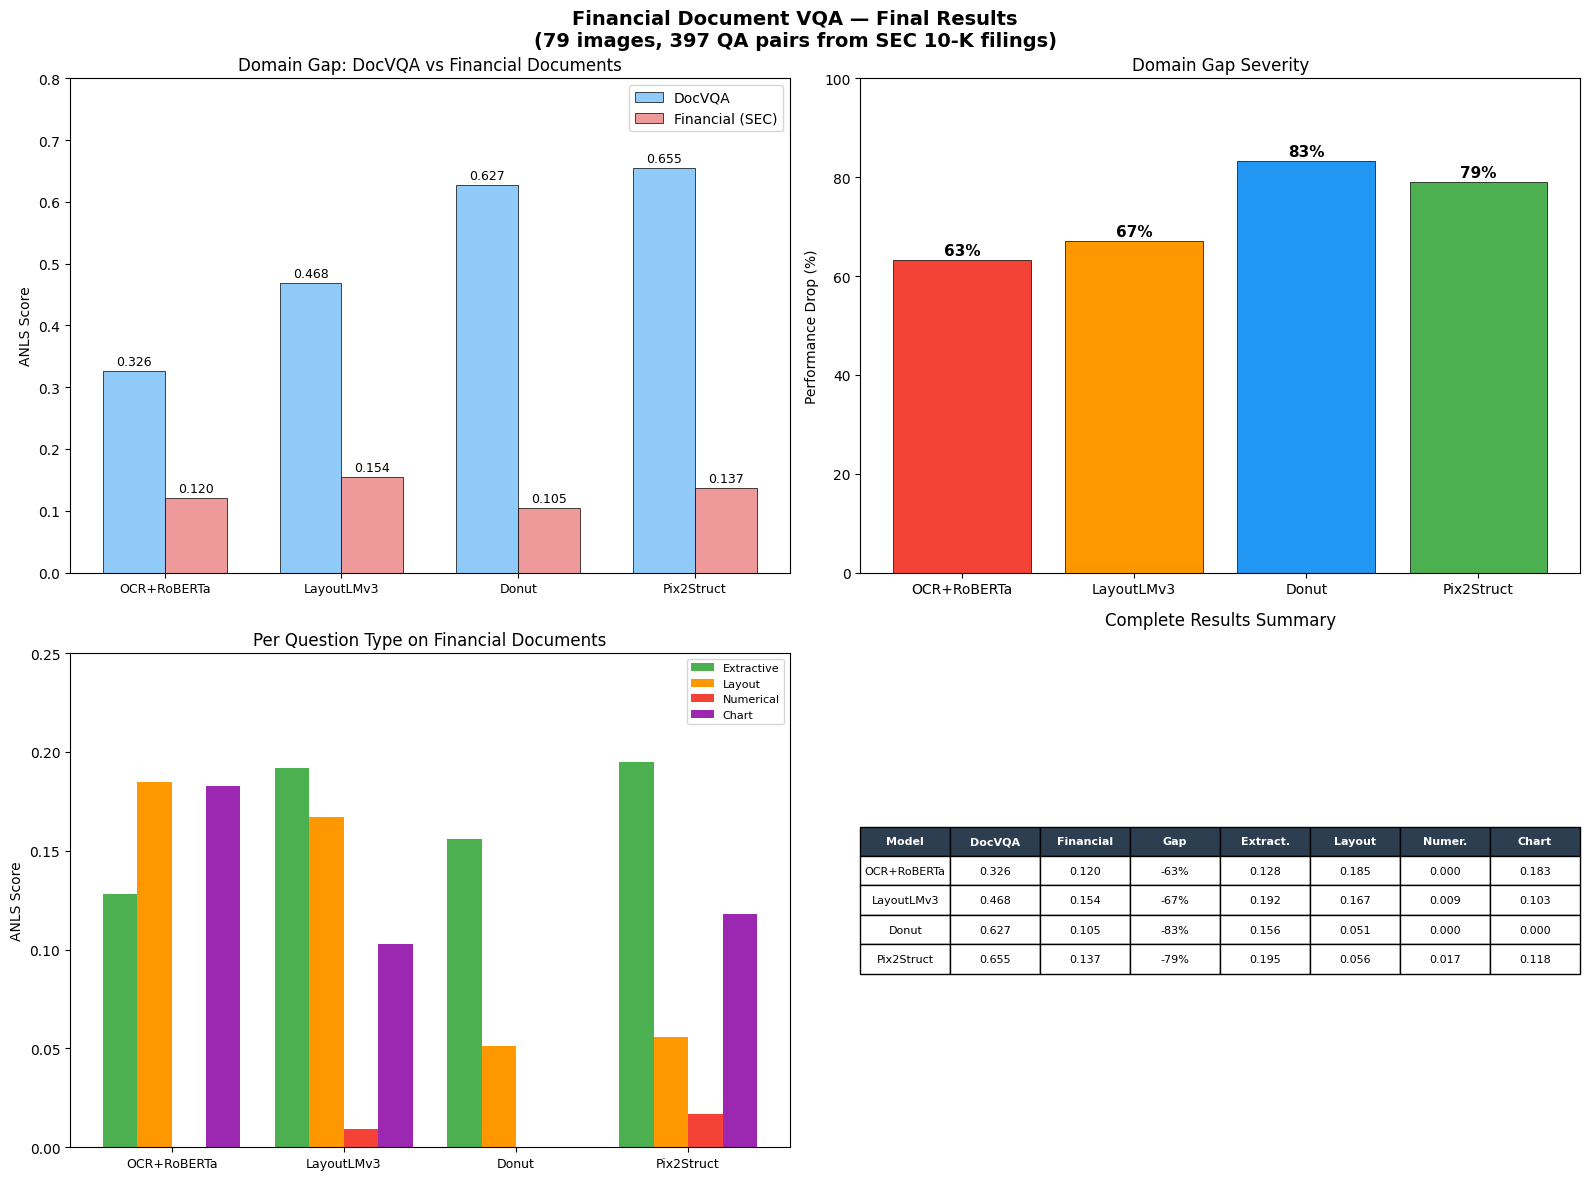

✓ Saved to outputs/final_domain_gap_analysis.png


In [7]:
# ============================================================
# CELL 7: Final Comparison Charts
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = ['OCR+RoBERTa', 'LayoutLMv3', 'Donut', 'Pix2Struct']
colors = ['#F44336', '#FF9800', '#2196F3', '#4CAF50']

docvqa_anls = [0.326, 0.468, 0.627, 0.655]
financial_anls = [0.120, 0.154, 0.105, 0.137]

extractive = [0.128, 0.192, 0.156, 0.195]
layout = [0.185, 0.167, 0.051, 0.056]
numerical = [0.000, 0.009, 0.000, 0.017]
chart_interp = [0.183, 0.103, 0.000, 0.118]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Financial Document VQA — Final Results\n(79 images, 397 QA pairs from SEC 10-K filings)',
             fontsize=14, fontweight='bold')

# --- Plot 1: DocVQA vs Financial ---
ax = axes[0, 0]
x = np.arange(len(models))
width = 0.35
bars1 = ax.bar(x - width/2, docvqa_anls, width, label='DocVQA', color='#90CAF9', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, financial_anls, width, label='Financial (SEC)', color='#EF9A9A', edgecolor='black', linewidth=0.5)
for bar, score in zip(bars1, docvqa_anls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score:.3f}', ha='center', fontsize=9)
for bar, score in zip(bars2, financial_anls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score:.3f}', ha='center', fontsize=9)
ax.set_ylabel('ANLS Score')
ax.set_title('Domain Gap: DocVQA vs Financial Documents')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.legend()
ax.set_ylim(0, 0.8)

# --- Plot 2: Domain gap % ---
ax = axes[0, 1]
gaps = [(d - f) / d * 100 for d, f in zip(docvqa_anls, financial_anls)]
bars = ax.bar(models, gaps, color=colors, edgecolor='black', linewidth=0.5)
for bar, gap in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{gap:.0f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Performance Drop (%)')
ax.set_title('Domain Gap Severity')
ax.set_ylim(0, 100)

# --- Plot 3: Per question type ---
ax = axes[1, 0]
x = np.arange(len(models))
width = 0.2
ax.bar(x - 1.5*width, extractive, width, label='Extractive', color='#4CAF50')
ax.bar(x - 0.5*width, layout, width, label='Layout', color='#FF9800')
ax.bar(x + 0.5*width, numerical, width, label='Numerical', color='#F44336')
ax.bar(x + 1.5*width, chart_interp, width, label='Chart', color='#9C27B0')
ax.set_ylabel('ANLS Score')
ax.set_title('Per Question Type on Financial Documents')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.legend(fontsize=8)
ax.set_ylim(0, 0.25)

# --- Plot 4: Summary table ---
ax = axes[1, 1]
ax.axis('off')
table_data = [
    ['Model', 'DocVQA', 'Financial', 'Gap', 'Extract.', 'Layout', 'Numer.', 'Chart'],
    ['OCR+RoBERTa', '0.326', '0.120', '-63%', '0.128', '0.185', '0.000', '0.183'],
    ['LayoutLMv3', '0.468', '0.154', '-67%', '0.192', '0.167', '0.009', '0.103'],
    ['Donut', '0.627', '0.105', '-83%', '0.156', '0.051', '0.000', '0.000'],
    ['Pix2Struct', '0.655', '0.137', '-79%', '0.195', '0.056', '0.017', '0.118'],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0], loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
for j in range(len(table_data[0])):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
ax.set_title('Complete Results Summary', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'final_domain_gap_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/final_domain_gap_analysis.png")